In [1]:
#Q.1)
import pandas as pd
df = pd.read_csv("ford_car_dataset.csv")
print("First 10 Rows")
print(df.head(10))
print("\nLast 5 Rows")
print(df.tail())
print("\nShape of Dataset:")
print(df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nColumns:")
print(df.columns)


First 10 Rows
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5   Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6     Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7   Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8     Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9    Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0

Last 5 Rows
        model  year  price transmission  mileage fuelType  tax   mpg  \
17961   B-MAX  2017   8999       Manual    

In [2]:
print("Missing Values")
print(df.isnull().sum())
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)
df = df.drop_duplicates()
print("\nNew Shape")
print(df.shape)


Missing Values
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Duplicate Rows: 154

New Shape
(17812, 9)


In [3]:
# Statistical summary
print(df.describe())

# Mean
print("\nMean Values")
print(df[['price','mileage','year']].mean())

# Median
print("\nMedian Values")
print(df[['price','mileage','year']].median())

# Minimum
print("\nMinimum Values")
print(df[['price','mileage','year']].min())

# Maximum
print("\nMaximum Values")
print(df[['price','mileage','year']].max())

               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  

Mean Values
price      12269.556310
mileage    23381.146362
year        2016.862

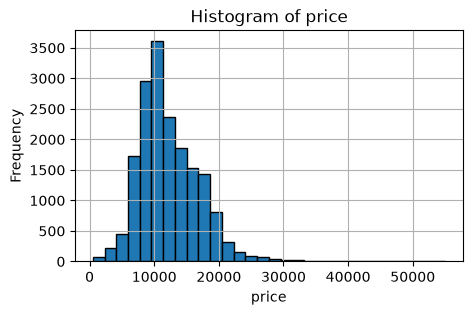

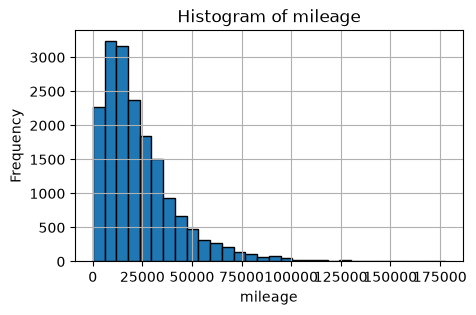

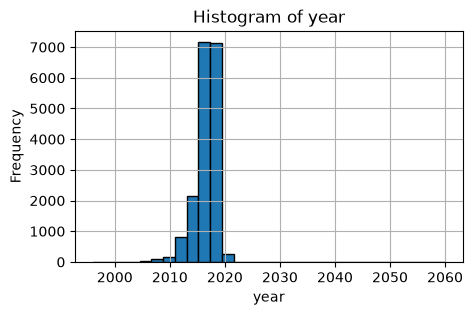

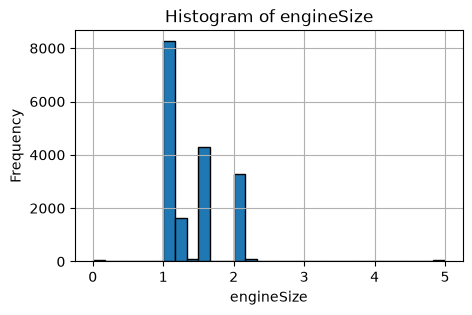

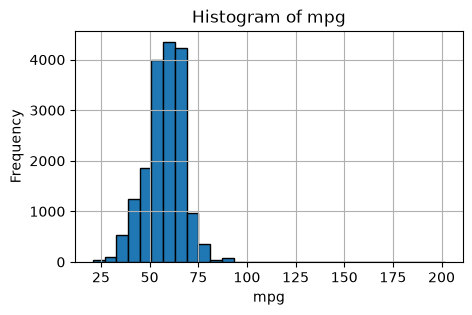

In [5]:
#Q.4) 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
numeric_columns = ['price', 'mileage', 'year', 'engineSize', 'mpg']
for col in numeric_columns:
    plt.figure(figsize=(5,3))
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()


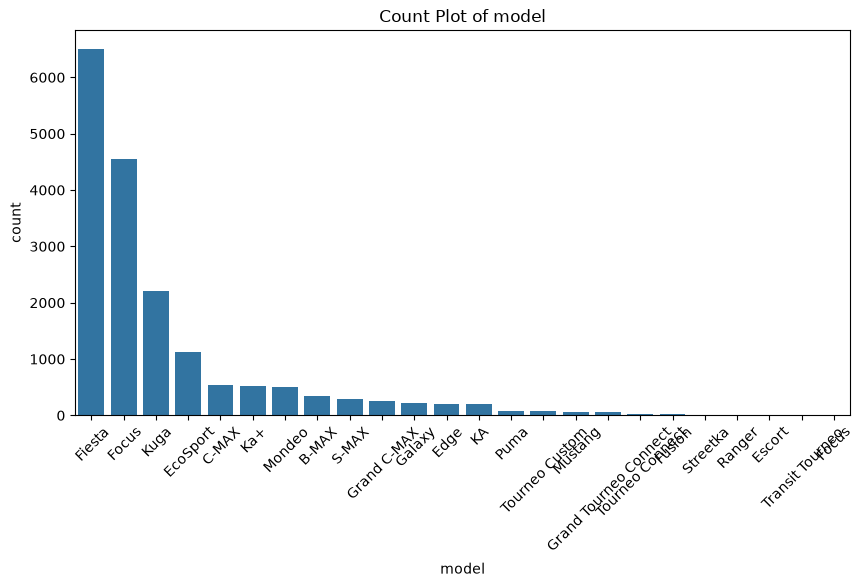

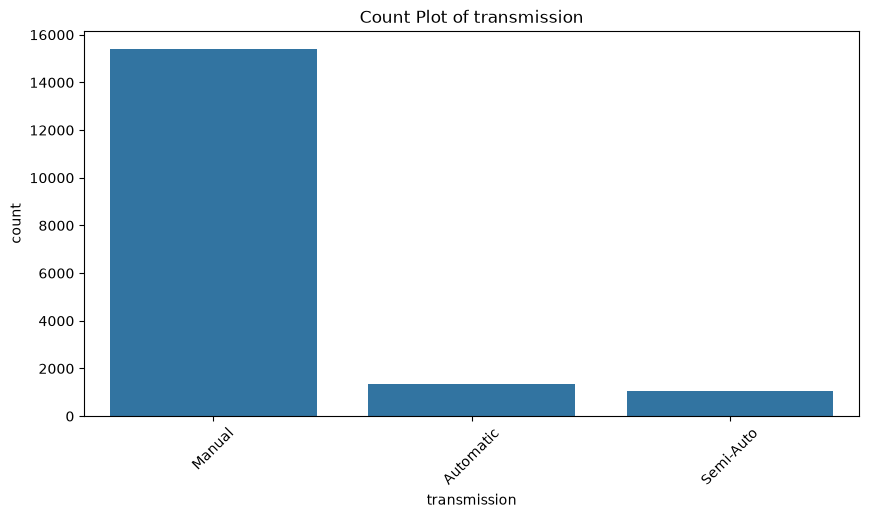

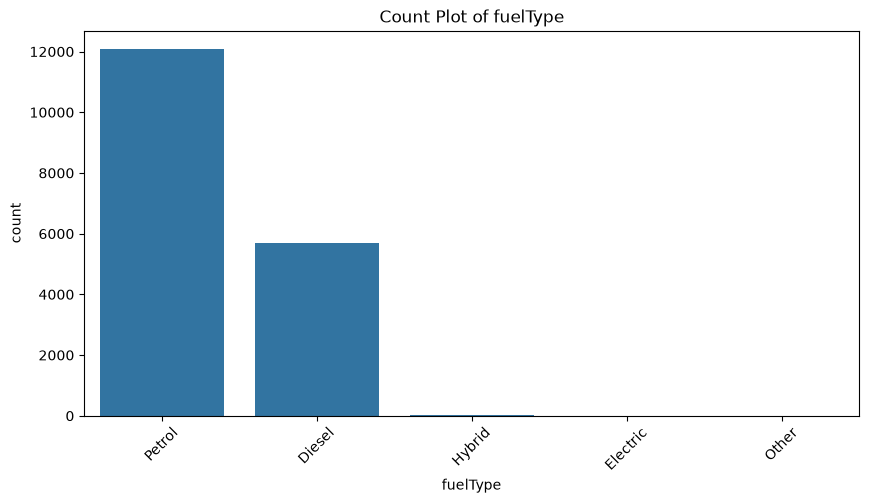

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Categorical columns
categorical_columns = ['model', 'transmission', 'fuelType']

# Count plots
for col in categorical_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()

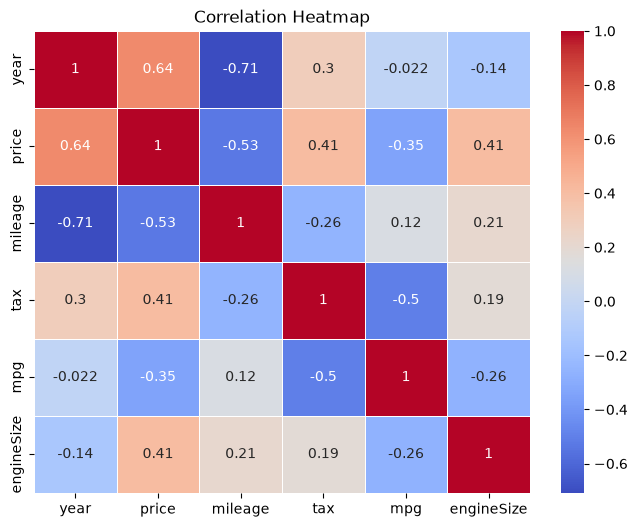

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [9]:
X = df.drop('price', axis=1)

y = df['price']

print("Independent Features:")
print(X.columns)

print("\nDependent Feature:")
print(y.name)

Independent Features:
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='str')

Dependent Feature:
price


In [10]:
# Show before encoding
print("Before Encoding")
print(df[['model', 'fuelType']].head())

# Apply One-Hot Encoding
encoded_df = pd.get_dummies(
    df,
    columns=['model', 'transmission', 'fuelType'],
    drop_first=True
)

# Show after encoding
print("\nAfter Encoding")
print(encoded_df.head())

Before Encoding
     model fuelType
0   Fiesta   Petrol
1    Focus   Petrol
2    Focus   Petrol
3   Fiesta   Petrol
4   Fiesta   Petrol

After Encoding
   year  price  mileage  tax   mpg  engineSize  model_ C-MAX  model_ EcoSport  \
0  2017  12000    15944  150  57.7         1.0         False            False   
1  2018  14000     9083  150  57.7         1.0         False            False   
2  2017  13000    12456  150  57.7         1.0         False            False   
3  2019  17500    10460  145  40.3         1.5         False            False   
4  2019  16500     1482  145  48.7         1.0         False            False   

   model_ Edge  model_ Escort  ...  model_ Tourneo Connect  \
0        False          False  ...                   False   
1        False          False  ...                   False   
2        False          False  ...                   False   
3        False          False  ...                   False   
4        False          False  ...                 

In [13]:
#Q.9)
from sklearn.preprocessing import StandardScaler
X = encoded_df.drop('price', axis=1)
y = encoded_df['price']
numeric_columns = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
scaler = StandardScaler()
X[numeric_columns] = scaler.fit_transform(X[numeric_columns])
print(X.head())


       year   mileage       tax       mpg  engineSize  model_ C-MAX  \
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561         False   
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561         False   
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561         False   
3  1.041726 -0.665405  0.510777 -1.737858    0.345325         False   
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561         False   

   model_ EcoSport  model_ Edge  model_ Escort  model_ Fiesta  ...  \
0            False        False          False           True  ...   
1            False        False          False          False  ...   
2            False        False          False          False  ...   
3            False        False          False           True  ...   
4            False        False          False           True  ...   

   model_ Tourneo Connect  model_ Tourneo Custom  model_ Transit Tourneo  \
0                   False                  False                   False   


Dataset Loaded Successfully
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0

Missing Values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Duplicate Rows: 154


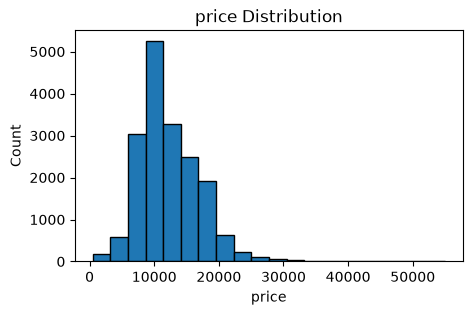

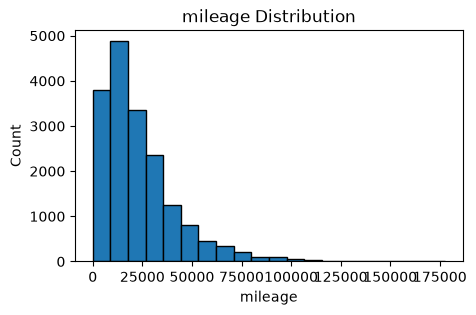

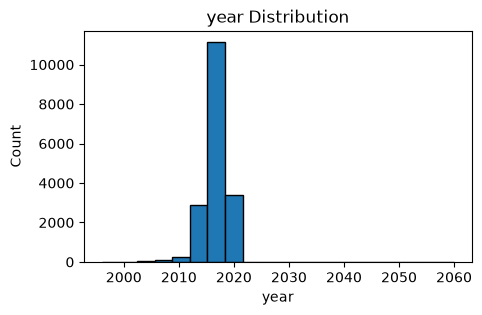

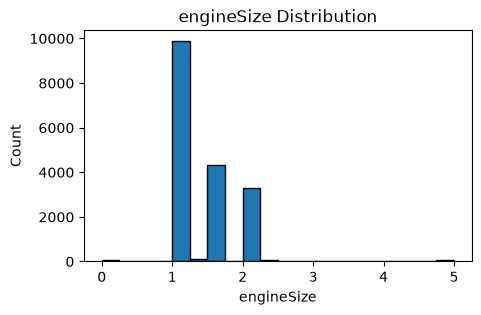

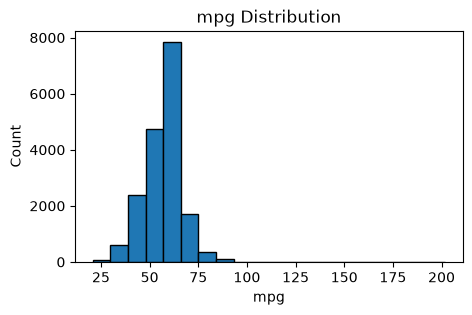

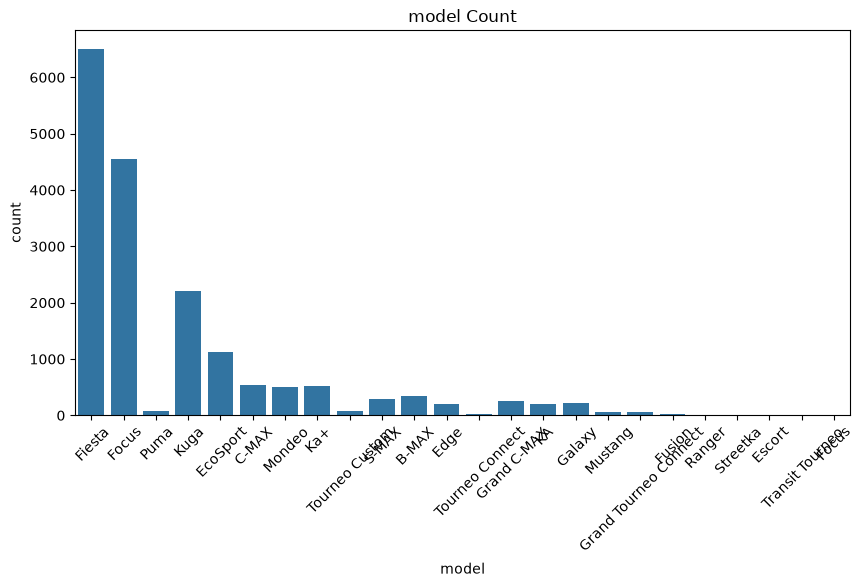

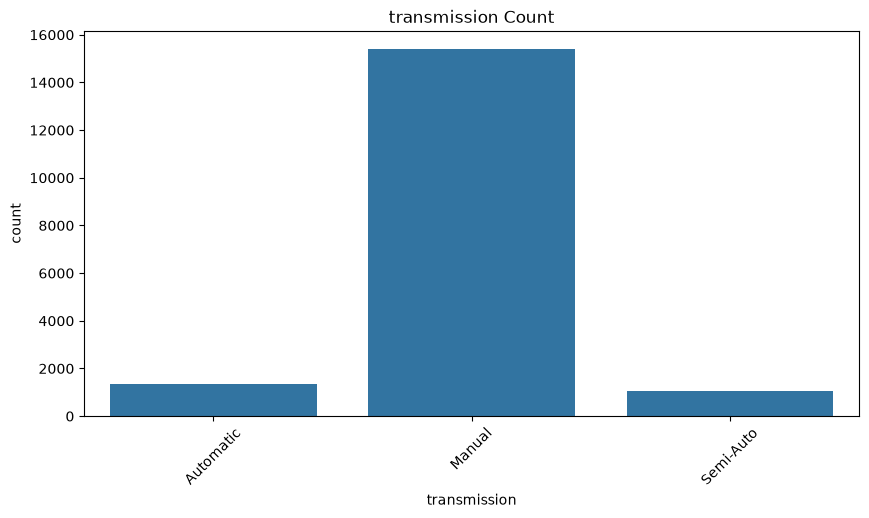

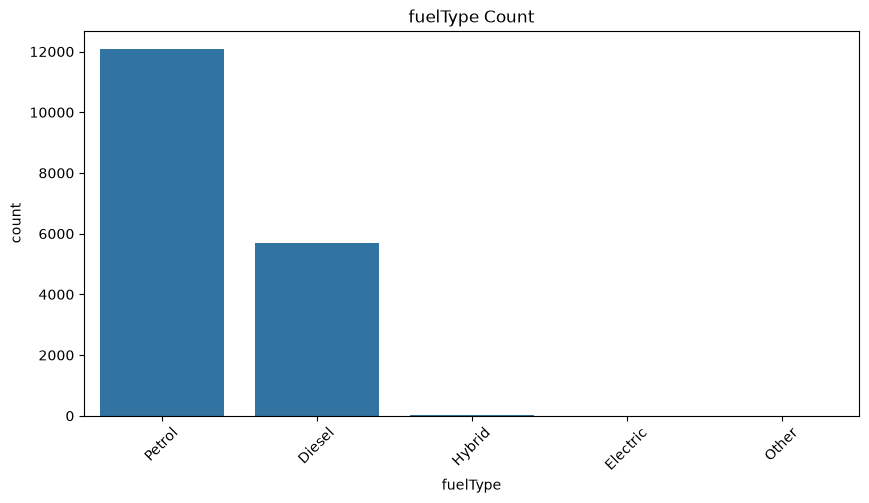

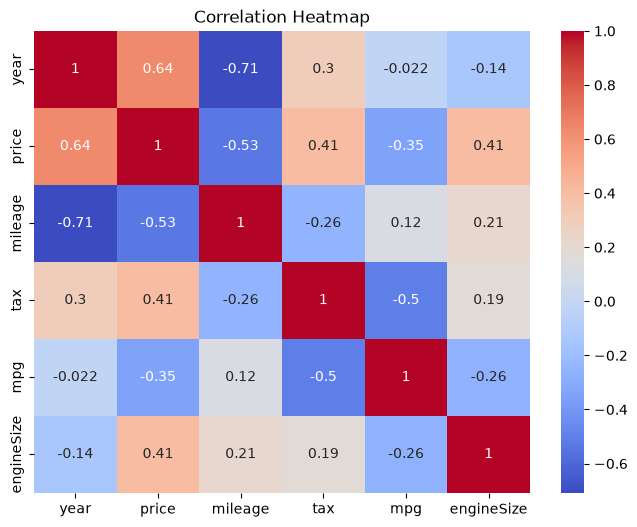


Input Features:
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='str')

Target Feature:
price

Dataset After Encoding
   year  price  mileage  tax   mpg  engineSize  model_ C-MAX  model_ EcoSport  \
0  2017  12000    15944  150  57.7         1.0         False            False   
1  2018  14000     9083  150  57.7         1.0         False            False   
2  2017  13000    12456  150  57.7         1.0         False            False   
3  2019  17500    10460  145  40.3         1.5         False            False   
4  2019  16500     1482  145  48.7         1.0         False            False   

   model_ Edge  model_ Escort  ...  model_ Tourneo Connect  \
0        False          False  ...                   False   
1        False          False  ...                   False   
2        False          False  ...                   False   
3        False          False  ...                   False   
4        False       

In [17]:
# Q10 - Complete Preprocessing Pipeline

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("ford_car_dataset.csv")

print("Dataset Loaded Successfully")
print(df.head())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Histogram
num_cols = ['price', 'mileage', 'year', 'engineSize', 'mpg']

for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.hist(df[col], bins=20, edgecolor='black')
    plt.title(col + " Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# Count plots
cat_cols = ['model', 'transmission', 'fuelType']

for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col + " Count")
    plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Independent and Dependent Variables
X = df.drop("price", axis=1)
y = df["price"]

print("\nInput Features:")
print(X.columns)

print("\nTarget Feature:")
print(y.name)

# One Hot Encoding
df = pd.get_dummies(df, columns=['model', 'transmission', 'fuelType'], drop_first=True)

print("\nDataset After Encoding")
print(df.head())

# Feature Scaling
X = df.drop("price", axis=1)
y = df["price"]

scaler = StandardScaler()

num_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
X[num_features] = scaler.fit_transform(X[num_features])

print("\nScaled Dataset")
print(X.head())

print("\nPreprocessing Completed Successfully")